In [1]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))


In [2]:
import torch
from torch import nn

from transformers import WhisperProcessor, WhisperForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, TrainableTokensModel

from src.model import WhisperAccentConfig, WhisperAccentForConditionalGeneration, WhisperAccentProcessor, register_whisper_accent
from src.train.dataset import DataCollatorSpeechSeq2SeqWithPadding, WhisperDataset
from src.train.train import processor_init, model_init, ModelArguments, LoraArguments, WhisperAccentTrainingArguments
from src.train.trainer import WhisperAccentTrainer
from src.model.tokenization import ACCENTS
from src.utils.loading import load_model_from_pretrained

register_whisper_accent()


/venv/whisper-accent/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
model, processor = load_model_from_pretrained("mavleo96/whisper-accent-small.en-pretrain-tokens-lambda-accent-0.1")

You are using a model of type whisper to instantiate a model of type whisper_accent. This is not supported for all configurations of models and can yield errors.
Loading weights: 100%|██████████| 479/479 [00:01<00:00, 359.66it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]   


In [10]:
model2 = model_init("openai/whisper-small.en", processor)

You are using a model of type whisper to instantiate a model of type whisper_accent. This is not supported for all configurations of models and can yield errors.
Loading weights: 100%|██████████| 479/479 [00:01<00:00, 359.60it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]   


In [11]:
accent_ids = model.generation_config.accent_to_id
accent_labels = sorted(list(accent_ids), key=lambda x: accent_ids[x])
accent_labels = [i[4:-2] for i in accent_labels]
accent_embeddings = model.get_decoder().embed_tokens.weight.data[-len(accent_labels):]


In [12]:
accent_embeddings2 = model2.get_decoder().embed_tokens.weight.data[-len(accent_labels):]


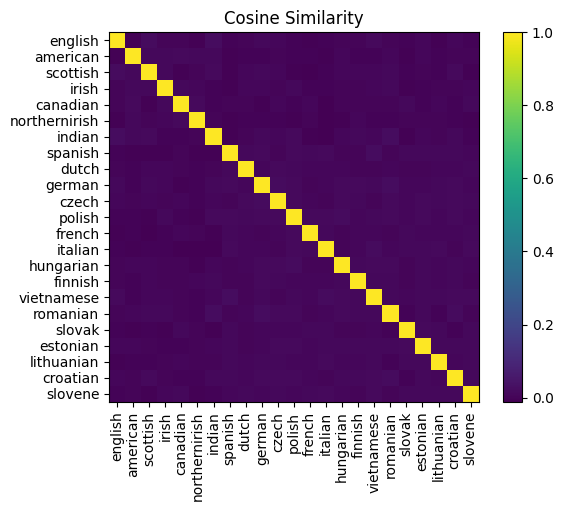

In [19]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F


def vizualize_embedding_similarity(embeddings, labels, ax=None, vmin=None, vmax=None):
    if ax is None:
        fig, ax = plt.subplots()

    normalized_embeddings = F.normalize(embeddings, p=2, dim=1)
    cosine_sim = torch.mm(normalized_embeddings, normalized_embeddings.t()).cpu().numpy()

    im = ax.imshow(cosine_sim)  # fix scale
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_title("Cosine Similarity")
    cbar = ax.figure.colorbar(im, ax=ax)

    return ax, im


# Plot and keep im handles
ax1, im1 = vizualize_embedding_similarity(accent_embeddings, accent_labels)


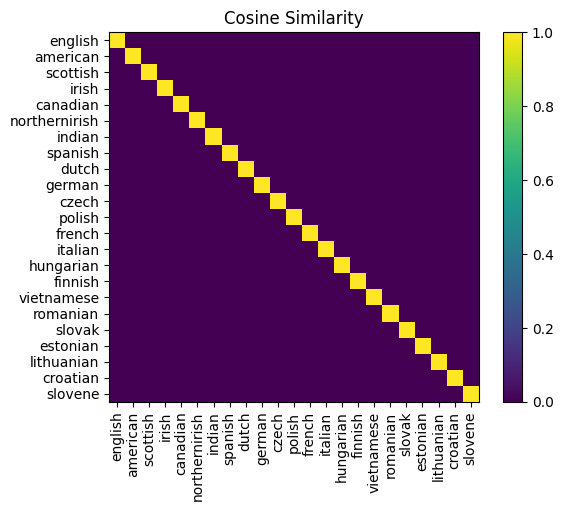

In [20]:
# Plot and keep im handles
ax1, im1 = vizualize_embedding_similarity(accent_embeddings2, accent_labels)
